In [60]:
import pandas as pd
import numpy as np
import random
import json
from collections import defaultdict

np.random.seed(36)
random.seed(36)

# ── Paths ────────────────────────────────────────────────────────────────────
TRAIN_PATH  = "C:/Users/huywz/Downloads/arxiv_dataset-20260616T015402Z-3-001/arxiv_dataset/train.csv"  
OUTPUT_PATH = "synthetic_users.json"

# ── Generation config ────────────────────────────────────────────────────────
N_USERS        = 1000
N_NEGATIVES    = 6     # số negative papers / user cho LTR
TRAIN_RATIO    = 0.8

In [48]:
df = pd.read_csv(TRAIN_PATH)

print(f"Total papers : {len(df):,}")
print(f"Columns      : {list(df.columns)}")
print(f"\nCategory distribution (top 15):")
print((df['primary_category'].value_counts()).tail(50))

Total papers : 136,238
Columns      : ['Unnamed: 0', 'paper_id', 'title', 'primary_category', 'authors', 'first_author', 'abstract', 'days_since_submission']

Category distribution (top 15):
primary_category
stat.OT              9
hep-th               8
nlin.CG              8
physics.plasm-ph     8
hep-ex               8
cond-mat.mes-hall    7
q-fin.MF             7
math.HO              7
math.DG              7
econ.TH              7
q-fin.PR             7
cond-mat.soft        6
nlin.CD              6
math.AT              6
physics.ins-det      6
hep-lat              5
cs.SC                4
cs.GL                4
cond-mat.str-el      4
math.AG              4
nucl-th              4
physics.acc-ph       4
econ.GN              3
astro-ph             3
cs.OS                3
physics.gen-ph       3
math.GT              3
astro-ph.EP          3
physics.space-ph     3
math.MG              3
astro-ph.GA          3
physics.ed-ph        3
astro-ph.HE          3
math.CT              3
math.GR   

In [49]:
# Build index: category → list of paper_ids (để sample nhanh)
cat_to_papers = defaultdict(list)
for _, row in df.iterrows():
    cat_to_papers[row['primary_category']].append(row['paper_id'])

all_categories = list(cat_to_papers.keys())
print(f"Unique primary categories: {len(all_categories)}")
print(all_categories)


Unique primary categories: 139
['cs.AI', 'cond-mat.dis-nn', 'cs.CC', 'cs.LO', 'cs.MA', 'cs.IR', 'cs.RO', 'cs.DB', 'cs.LG', 'cs.CL', 'cs.PL', 'cs.DC', 'cs.PF', 'cs.NE', 'cs.CE', 'cs.CG', 'cs.NI', 'cs.GT', 'cs.CV', 'cs.HC', 'cs.CR', 'cs.OH', 'cs.SE', 'cs.DM', 'cs.MS', 'cs.DS', 'cs.CY', 'math.LO', 'nlin.AO', 'q-bio.QM', 'quant-ph', 'cs.DL', 'q-bio.NC', 'cs.GR', 'cs.MM', 'cs.SC', 'physics.data-an', 'stat.ML', 'cs.AR', 'math.OC', 'cs.SY', 'math.CO', 'astro-ph.IM', 'stat.ME', 'stat.CO', 'astro-ph.CO', 'cs.SI', 'q-fin.RM', 'math.PR', 'stat.OT', 'cs.GL', 'stat.AP', 'math.NT', 'cs.SD', 'q-fin.GN', 'math.HO', 'eess.SP', 'q-fin.EC', 'cs.ET', 'cs.OS', 'physics.med-ph', 'eess.IV', 'eess.AS', 'q-bio.PE', 'q-fin.CP', 'physics.comp-ph', 'nlin.CG', 'physics.geo-ph', 'math.DG', 'hep-th', 'q-fin.ST', 'q-bio.GN', 'q-fin.TR', 'econ.TH', 'q-bio.MN', 'cs.FL', 'physics.optics', 'physics.flu-dyn', 'physics.gen-ph', 'econ.EM', 'math.AT', 'physics.soc-ph', 'astro-ph.GA', 'nucl-ex', 'gr-qc', 'physics.ao-ph', 'mat

In [50]:
USER_ARCHETYPES = {
    "CV_researcher": {
        "primary"  : ["cs.CV"],
        "secondary": ["cs.LG", "cs.RO"],
    },
    "NLP_researcher": {
        "primary"  : ["cs.CL"],
        "secondary": ["cs.IR", "cs.LG", "cs.AI"],
    },
    "ML_theorist": {
        "primary"  : ["cs.LG", "stat.ML"],
        "secondary": ["cs.AI", "math.OC"],
    },
    "AI_researcher": {
        "primary"  : ["cs.AI"],
        "secondary": ["cs.LG", "cs.CL"],
    },
    "multimodal_researcher": {
        "primary"  : ["cs.CV", "cs.CL"],
        "secondary": ["cs.LG", "cs.AI"],
    },
}

# Lọc chỉ giữ các category có tồn tại trong dataset
def filter_available_cats(cat_list):
    return [c for c in cat_list if c in cat_to_papers]

for name, arch in USER_ARCHETYPES.items():
    arch['primary']   = filter_available_cats(arch['primary'])
    arch['secondary'] = filter_available_cats(arch['secondary'])
    print(f"{name:30s} | primary={arch['primary']} | secondary={arch['secondary']}")

CV_researcher                  | primary=['cs.CV'] | secondary=['cs.LG', 'cs.RO']
NLP_researcher                 | primary=['cs.CL'] | secondary=['cs.IR', 'cs.LG', 'cs.AI']
ML_theorist                    | primary=['cs.LG', 'stat.ML'] | secondary=['cs.AI', 'math.OC']
AI_researcher                  | primary=['cs.AI'] | secondary=['cs.LG', 'cs.CL']
multimodal_researcher          | primary=['cs.CV', 'cs.CL'] | secondary=['cs.LG', 'cs.AI']


In [51]:
USER_TYPES = {
    "new_user"   : {"n_papers_range": (3,  8),  "weight": 0.20},  # cold-ish start
    "regular"    : {"n_papers_range": (10, 25), "weight": 0.50},  # main segment
    "power_user" : {"n_papers_range": (30, 60), "weight": 0.30},  # heavy reader
}

USER_TYPE_NAMES   = list(USER_TYPES.keys())
USER_TYPE_WEIGHTS = [USER_TYPES[t]['weight'] for t in USER_TYPE_NAMES]

In [52]:
def sample_papers_for_archetype(archetype: dict, n_papers: int) -> list:
    """
    Sample paper_ids theo phân bổ category của archetype.
    - 70% từ primary categories
    - 20% từ secondary categories (nếu có)
    - 10% random noise
    """
    papers = []
    
    n_primary   = max(1, int(n_papers * 0.70))
    n_secondary = max(0, int(n_papers * 0.20)) if archetype['secondary'] else 0
    n_noise     = n_papers - n_primary - n_secondary

    # Primary
    primary_pool = []
    for cat in archetype['primary']:
        primary_pool.extend(cat_to_papers.get(cat, []))
    if primary_pool:
        papers += random.choices(primary_pool, k=n_primary)

    # Secondary
    if n_secondary > 0:
        secondary_pool = []
        for cat in archetype['secondary']:
            secondary_pool.extend(cat_to_papers.get(cat, []))
        if secondary_pool:
            papers += random.choices(secondary_pool, k=n_secondary)

    # Noise
    if n_noise > 0:
        noise_pool = df['paper_id'].tolist()
        papers += random.choices(noise_pool, k=n_noise)

    # Deduplicate (giữ nguyên thứ tự, bỏ duplicate)
    seen = set()
    unique_papers = []
    for p in papers:
        if p not in seen:
            seen.add(p)
            unique_papers.append(p)

    # Nếu sau dedup còn thiếu thì sample thêm random
    while len(unique_papers) < n_papers:
        extra = random.choice(df['paper_id'].tolist())
        if extra not in seen:
            seen.add(extra)
            unique_papers.append(extra)

    return unique_papers

In [53]:
def generate_days_ago(n_papers: int) -> list:
    """
    Sinh `days_ago` cho từng paper trong reading history.

    Convention:
      - Paper cuối cùng (mới nhất, sẽ bị giấu trong LOO) → days_ago = 0
      - Các paper trước đó → days_ago tăng dần (đọc xa hơn trong quá khứ)
      - Phân bố: exponential với scale=45 → tập trung vào 90 ngày gần nhất,
        tối đa 180 ngày (6 tháng) để phù hợp timespan của dataset (Sep25–Apr26)
    """
    if n_papers == 1:
        return [0]

    # n_papers - 1 khoảng cách giữa các lần đọc liên tiếp
    # Dùng exponential để có reading sessions (đọc dồn rồi nghỉ)
    gaps = np.random.exponential(scale=45 / (n_papers - 1), size=n_papers - 1)
    gaps = np.clip(gaps, 0.5, None)   # tối thiểu 0.5 ngày giữa 2 lần đọc

    # days_ago của paper thứ i tính từ paper cuối
    # Paper cuối = 0, paper trước đó = gap[-1], ...
    cumulative = np.cumsum(gaps[::-1])[::-1]  # reverse cumsum
    days_ago   = np.append(cumulative, 0)     # paper cuối = 0
    days_ago   = np.clip(days_ago, 0, 180).astype(int).tolist()

    return days_ago

In [54]:
def split_loo(reading_history: list) -> tuple:
    """
    Leave-One-Out split: giấu paper CUỐI CÙNG (days_ago = 0, tức mới nhất).
    
    Trả về:
      train_history : list of (paper_id, days_ago) — dùng để build user profile
      target_paper  : paper_id                     — ground truth cho evaluation
    """
    # reading_history đã được sắp xếp theo days_ago giảm dần
    # → phần tử cuối = paper mới nhất (days_ago = 0)
    train_history = reading_history[:-1]
    target_paper  = reading_history[-1][0]   # chỉ lấy paper_id
    return train_history, target_paper


def get_negative_papers(target_paper_id: str, archetype: dict, n: int) -> list:
    """
    Sample negative papers cho LTR training:
    - Ưu tiên lấy từ các category KHÁC với primary của archetype
      → tạo contrast rõ ràng để LTR học được
    """
    primary_cats = set(archetype['primary'])
    negative_pool = [
        pid for pid, row in zip(df['paper_id'], df.itertuples())
        if pid != target_paper_id and row.primary_category not in primary_cats
    ]

    if len(negative_pool) < n:
        negative_pool = [pid for pid in df['paper_id'] if pid != target_paper_id]

    return random.sample(negative_pool, min(n, len(negative_pool)))

In [61]:
def generate_synthetic_users(n_users: int = N_USERS) -> list:
    """
    Generate N synthetic users.

    Mỗi user là một dict:
    {
        "user_id"       : str,
        "archetype"     : str,
        "user_type"     : str,
        "train_history" : [(paper_id, days_ago), ...],   # sorted: oldest → newest
        "target_paper"  : str,                           # LOO held-out paper
        "negative_papers": [paper_id, ...],              # for LTR training
    }
    """
    users = []
    archetype_names = list(USER_ARCHETYPES.keys())

    for i in range(n_users):
        # ── 1. Sample archetype & user type ───────────────────────────────
        archetype_name = random.choice(archetype_names)
        archetype      = USER_ARCHETYPES[archetype_name]

        user_type_name = random.choices(USER_TYPE_NAMES, weights=USER_TYPE_WEIGHTS, k=1)[0]
        n_papers_range = USER_TYPES[user_type_name]['n_papers_range']
        n_papers       = random.randint(*n_papers_range)

        # Đảm bảo đủ paper để LOO (cần ít nhất 2: 1 train + 1 target)
        n_papers = max(n_papers, 2)

        # ── 2. Sample papers theo archetype ───────────────────────────────
        paper_ids = sample_papers_for_archetype(archetype, n_papers)

        # ── 3. Gán days_ago (temporal realism) ────────────────────────────
        days_ago_list = generate_days_ago(len(paper_ids))

        # Ghép lại và sort theo days_ago GIẢM dần → tăng dần
        # (paper cũ nhất đầu tiên, paper mới nhất = 0 ở cuối)
        reading_history = sorted(
            list(zip(paper_ids, days_ago_list)),
            key=lambda x: x[1],
            reverse=True   # oldest first
        )

        # ── 4. Leave-One-Out split ─────────────────────────────────────────
        train_history, target_paper = split_loo(reading_history)

        # ── 5. Sample negatives (for LTR training) ─────────────────────────
        negatives = get_negative_papers(target_paper, archetype, n=N_NEGATIVES)

        users.append({
            "user_id"        : f"user_{i:04d}",
            "archetype"      : archetype_name,
            "user_type"      : user_type_name,
            "train_history"  : [(pid, int(d)) for pid, d in train_history],
            "target_paper"   : target_paper,
            "negative_papers": negatives,
        })

    return users


print("Generating synthetic users...")
users = generate_synthetic_users(N_USERS)
print(f"✓ Generated {len(users)} users")

Generating synthetic users...
✓ Generated 1000 users


In [62]:
# Xem một user mẫu
sample = users[1]
print(f"user_id      : {sample['user_id']}")
print(f"archetype    : {sample['archetype']}")
print(f"user_type    : {sample['user_type']}")
print(f"history size : {len(sample['train_history'])} papers")
print(f"target_paper : {sample['target_paper']}")
print(f"\ntrain_history (oldest → newest):")
for pid, d in sample['train_history']:
    print(f"  paper_id={pid:20s}  days_ago={d}")
print(f"\nnegative_papers: {sample['negative_papers']}")

user_id      : user_0001
archetype    : ML_theorist
user_type    : power_user
history size : 42 papers
target_paper : abs-2403.17853v1

train_history (oldest → newest):
  paper_id=abs-2501.01844v2      days_ago=40
  paper_id=abs-2303.11000v1      days_ago=37
  paper_id=abs-1210.5394v1       days_ago=36
  paper_id=abs-1910.00888v1      days_ago=35
  paper_id=abs-1611.08903v1      days_ago=34
  paper_id=abs-1905.07234v2      days_ago=34
  paper_id=abs-1605.00404v1      days_ago=33
  paper_id=abs-2002.09469v4      days_ago=32
  paper_id=abs-2211.04208v1      days_ago=31
  paper_id=abs-2106.00563v3      days_ago=28
  paper_id=abs-2001.01394v2      days_ago=26
  paper_id=abs-2006.01681v4      days_ago=25
  paper_id=abs-2202.09284v2      days_ago=24
  paper_id=abs-2309.17194v2      days_ago=24
  paper_id=abs-1704.00003v1      days_ago=23
  paper_id=abs-1809.09369v2      days_ago=23
  paper_id=abs-1810.00322v4      days_ago=22
  paper_id=abs-2008.06668v1      days_ago=22
  paper_id=abs-1704.0

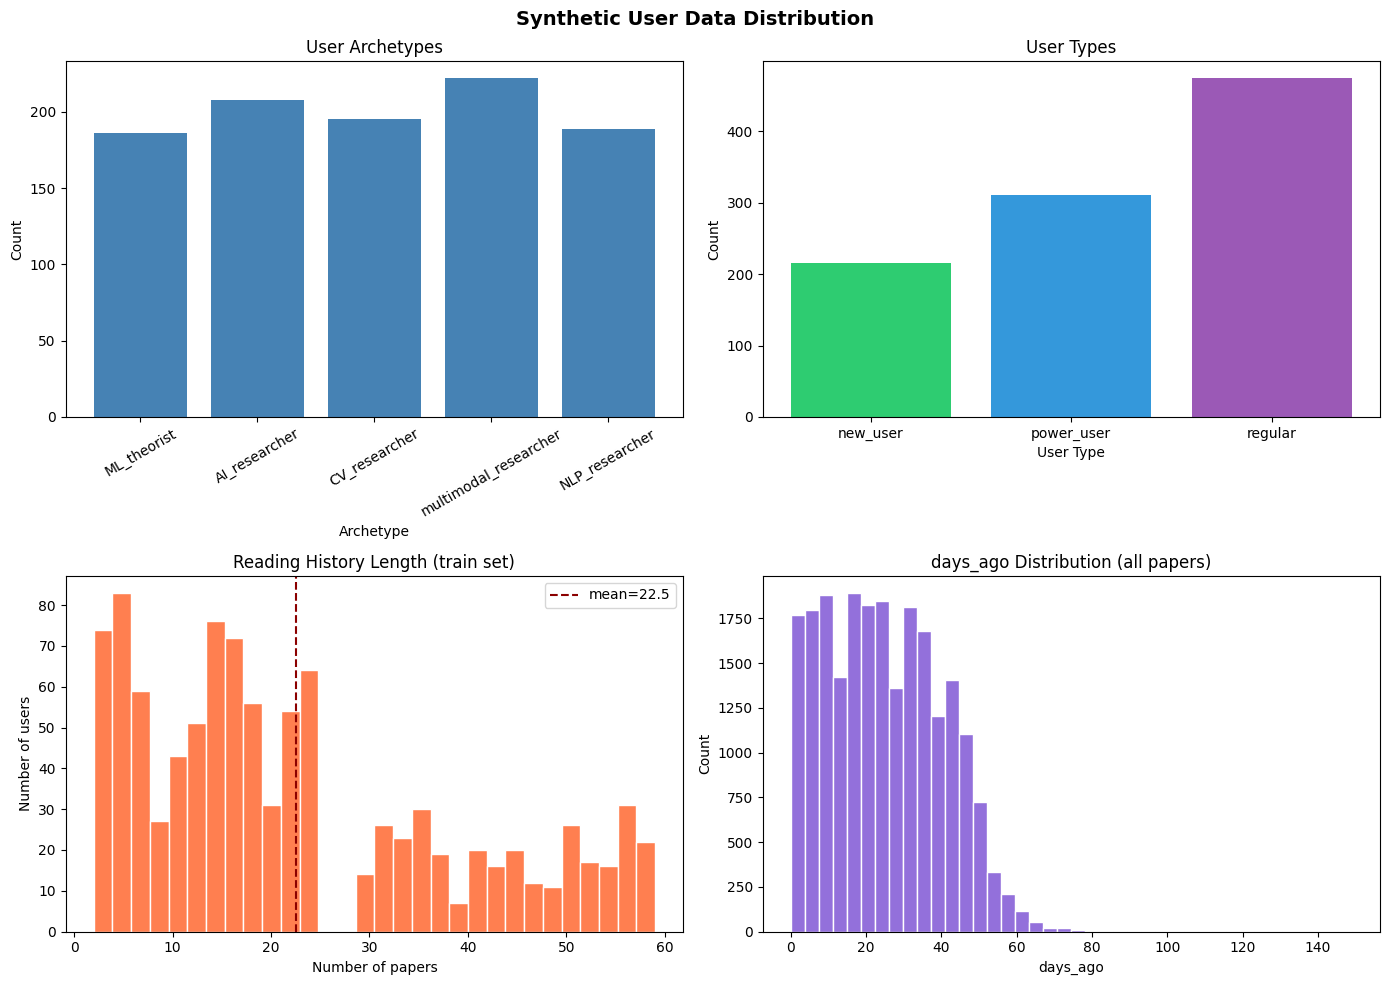

✓ Saved: user_generation_stats.png


In [63]:
import matplotlib.pyplot as plt

# ── 7.1 Archetype distribution ─────────────────────────────────────────────
archetype_counts = defaultdict(int)
for u in users:
    archetype_counts[u['archetype']] += 1

# ── 7.2 User type distribution ─────────────────────────────────────────────
usertype_counts = defaultdict(int)
for u in users:
    usertype_counts[u['user_type']] += 1

# ── 7.3 History length distribution ────────────────────────────────────────
history_lengths = [len(u['train_history']) for u in users]

# ── 7.4 days_ago distribution (flatten tất cả) ─────────────────────────────
all_days_ago = [d for u in users for _, d in u['train_history']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Synthetic User Data Distribution', fontsize=14, fontweight='bold')

# Plot 1: Archetype
axes[0,0].bar(archetype_counts.keys(), archetype_counts.values(), color='steelblue')
axes[0,0].set_title('User Archetypes')
axes[0,0].set_xlabel('Archetype')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)

# Plot 2: User type
axes[0,1].bar(usertype_counts.keys(), usertype_counts.values(),
              color=['#2ecc71', '#3498db', '#9b59b6'])
axes[0,1].set_title('User Types')
axes[0,1].set_xlabel('User Type')
axes[0,1].set_ylabel('Count')

# Plot 3: History length
axes[1,0].hist(history_lengths, bins=30, color='coral', edgecolor='white')
axes[1,0].set_title('Reading History Length (train set)')
axes[1,0].set_xlabel('Number of papers')
axes[1,0].set_ylabel('Number of users')
axes[1,0].axvline(np.mean(history_lengths), color='darkred', linestyle='--',
                  label=f'mean={np.mean(history_lengths):.1f}')
axes[1,0].legend()

# Plot 4: days_ago
axes[1,1].hist(all_days_ago, bins=40, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('days_ago Distribution (all papers)')
axes[1,1].set_xlabel('days_ago')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
#plt.savefig('user_generation_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: user_generation_stats.png")

In [66]:
# ── Summary stats ─────────────────────────────────────────────────────────
print("=" * 50)
print("GENERATION SUMMARY")
print("=" * 50)
print(f"Total users generated  : {len(users)}")
print(f"\nArchetype breakdown:")
for k, v in sorted(archetype_counts.items()):
    print(f"  {k:30s}: {v}")
print(f"\nUser type breakdown:")
for k, v in sorted(usertype_counts.items()):
    print(f"  {k:15s}: {v}")
print(f"\nHistory length stats:")
print(f"  min    : {min(history_lengths)}")
print(f"  max    : {max(history_lengths)}")
print(f"  mean   : {np.mean(history_lengths):.2f}")
print(f"  median : {np.median(history_lengths):.1f}")
print(f"\ndays_ago stats:")
print(f"  min    : {min(all_days_ago)}")
print(f"  max    : {max(all_days_ago)}")
print(f"  mean   : {np.mean(all_days_ago):.2f}")

GENERATION SUMMARY
Total users generated  : 1000

Archetype breakdown:
  AI_researcher                 : 208
  CV_researcher                 : 195
  ML_theorist                   : 186
  NLP_researcher                : 189
  multimodal_researcher         : 222

User type breakdown:
  new_user       : 216
  power_user     : 310
  regular        : 474

History length stats:
  min    : 2
  max    : 59
  mean   : 22.50
  median : 18.0

days_ago stats:
  min    : 0
  max    : 149
  mean   : 24.80


In [ ]:
random.shuffle(users)
split_idx   = int(N_USERS * TRAIN_RATIO)
# train_users = users[:split_idx]
# test_users  = users[split_idx:]

# print(f"Train users : {len(train_users)}  → {len(train_users) * N_NEGATIVES} LTR pairwise samples")
# print(f"Test users  : {len(test_users)}   → for NDCG@K, Precision@K evaluation")

Train users : 800  → 4800 LTR pairwise samples
Test users  : 200   → for NDCG@K, Precision@K evaluation


In [67]:
output = {
    "meta": {
        "n_users"      : N_USERS,
        "n_negatives"  : N_NEGATIVES,
        "train_ratio"  : TRAIN_RATIO,
        "random_seed"  : 42,
    },
    "train": users,
}

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"✓ Saved to: {OUTPUT_PATH}")
print(f"  File size: {__import__('os').path.getsize(OUTPUT_PATH) / 1024:.1f} KB")

✓ Saved to: synthetic_users.json
  File size: 1881.1 KB


In [68]:
errors = []

for u in users:
    uid = u['user_id']

    # 1. Phải có ít nhất 1 paper trong train_history
    if len(u['train_history']) < 1:
        errors.append(f"{uid}: train_history rỗng")

    # 2. target_paper không được nằm trong train_history
    train_ids = {pid for pid, _ in u['train_history']}
    if u['target_paper'] in train_ids:
        errors.append(f"{uid}: target_paper bị leak vào train_history")

    # 3. days_ago phải tăng dần từ cuối lên đầu (oldest first)
    days = [d for _, d in u['train_history']]
    if days != sorted(days, reverse=True):
        errors.append(f"{uid}: days_ago không được sort đúng")

    # 4. Không có negative nào trùng target
    if u['target_paper'] in u['negative_papers']:
        errors.append(f"{uid}: target_paper nằm trong negative_papers")

    # 5. days_ago trong range hợp lệ
    invalid = [(pid, d) for pid, d in u['train_history'] if d < 0 or d > 180]
    if invalid:
        errors.append(f"{uid}: days_ago ngoài range [0, 180]: {invalid}")

if errors:
    print(f"❌ Found {len(errors)} issues:")
    for e in errors[:10]:
        print(f"  - {e}")
else:
    print(f"✓ All {len(users)} users passed sanity checks")

✓ All 1000 users passed sanity checks
